**Source**: Chirag Shah's A Hand-on Introduction to ML (Cambridge University Press, 2023)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time
import csv
from tensorflow.python.keras.layers import LSTM
from tensorflow.python.keras.layers import Dense, Activation, Dropout
from tensorflow.python.keras.models import Sequential, load_model
# import tensorflow.keras.layers as ly

2025-04-21 12:08:52.939398: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


ImportError: cannot import name 'LSTM' from 'tensorflow.python.keras.layers' (/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/tensorflow/python/keras/layers/__init__.py)

In [53]:
import tensorflow as tf
print(tf.__version__)
# print(dir(tf.keras.python))  # Check if LSTM is listed
from tensorflow.python.keras import backend as K
K.clear_session()

2.16.2


In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def create_lstm_model(input_shape, num_features):
    """
    Creates an LSTM model for time series prediction.

    Args:
        input_shape (tuple): Shape of the input data (timesteps, features).
        num_features (int): Number of features in the input data.

    Returns:
        Sequential: Compiled LSTM model.
    """
    model = Sequential()
    model.add(LSTM(units=50, activation='relu', input_shape=input_shape))
    model.add(Dense(num_features))  # Output layer with num_features for the next timestep
    model.compile(optimizer='adam', loss='mse')
    return model

def train_lstm(X_train, y_train, X_test, y_test, result_mean, epochs=10, batch_size=32):
    """
    Trains an LSTM model on the provided data and evaluates its performance.

    Args:
        X_train (np.array): Training input data (num_samples, timesteps, features).
        y_train (np.array): Training target data (num_samples, features).
        X_test (np.array): Testing input data (num_samples, timesteps, features).
        y_test (np.array): Testing target data (num_samples, features).
        result_mean (np.array): Mean of the original data used for shifting.
        epochs (int): Number of training epochs.
        batch_size (int): Batch size for training.

    Returns:
        tuple: Trained LSTM model, predictions on the test set (original scale),
               true values (original scale), and evaluation metrics.
    """
    timesteps = X_train.shape[1]
    num_features = X_train.shape[2]
    model = create_lstm_model((timesteps, num_features), num_features)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                      validation_data=(X_test, y_test), verbose=1)

    # Evaluate the model on the test set
    loss = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Mean Squared Error (MSE) (scaled): {loss:.4f}")

    # Make predictions on the test set
    predicted_scaled = model.predict(X_test)

    # Rescale predictions and true values back to the original scale
    predicted_original = predicted_scaled + result_mean
    y_test_original = y_test + result_mean

    # Evaluate performance on the original scale
    mse_original = mean_squared_error(y_test_original, predicted_original)
    mae_original = mean_absolute_error(y_test_original, predicted_original)
    r2_original = r2_score(y_test_original, predicted_original)

    print("\nEvaluation Metrics (Original Scale):")
    print(f"Mean Squared Error (MSE): {mse_original:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_original:.4f}")
    print(f"R-squared (R2): {r2_original:.4f}")

    return model, predicted_original, y_test_original, {'mse': mse_original, 'mae': mae_original, 'r2': r2_original}

# Assuming you have already run the data_bike_num_multi_feature function
# and have X_train, y_train, X_test, y_test, and result_mean

# Example usage:
if __name__ == "__main__":
    import csv

    bikes_data = []
    def data_bike_num_multi_feature(path_to_dataset='bike_rnn.csv',
                                        sequence_length=4,
                                        ratio=1.0,
                                        feature_indices=[0, 1, 2],
                                        train_percentage=0.8):
        max_values = int(ratio * 45949)
        with open(path_to_dataset) as f:
            data = csv.reader(f, delimiter=",")
            next(data, None)  # skip the headers
            nb_of_values = 0
            for line in data:
                try:
                    features = [float(line[i]) for i in feature_indices]
                    bikes_data.append(features)
                    nb_of_values += 1
                except ValueError:
                    pass
                if nb_of_values >= max_values:
                    break
        print ("Data loaded from csv. Formatting...")
        print(len(bikes_data))

        result = []
        for index in range(len(bikes_data) - sequence_length):
            result.append(bikes_data[index: index + sequence_length])
        result = np.array(result)  # shape (N, 4, 3) where N is the number of sequences
        result_mean = result.mean(axis=(0, 1)) # Calculate mean across all sequences and timesteps for each feature
        result -= result_mean
        print("Shift: ", result_mean)
        print ("Data: ", result.shape)
        row = int(round(train_percentage * result.shape[0])) # Calculate the split based on train_percentage
        train = result[:row, :]
        np.random.shuffle(train)
        X_train = train[:, :-1] # Shape (M, 3, 3) where M is the number of training sequences
        y_train = train[:, -1]  # Shape (M, 3) - the target is the next timestep's 3 features
        X_test = result[row:, :-1] # Shape (P, 3, 3) where P is the number of testing sequences
        y_test = result[row:, -1]  # Shape (P, 3)
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], len(feature_indices))) # Shape (M, 3, 3)
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], len(feature_indices)))   # Shape (P, 3, 3)
        return [X_train, y_train, X_test, y_test, result_mean]

    # Load and prepare the data
    X_train, y_train, X_test, y_test, result_mean = data_bike_num_multi_feature(
        path_to_dataset='bike_rnn.csv',  # Replace with your actual path
        sequence_length=4,
        feature_indices=[0, 1, 2],  # Adjust based on your feature columns
        train_percentage=0.8
    )

    # Train the LSTM model and get predictions and metrics
    lstm_model, predictions, y_test_original, metrics = train_lstm(
        X_train, y_train, X_test, y_test, result_mean, epochs=20, batch_size=64
    )

    # 'predictions' now contains the model's predictions on the test set,
    # rescaled to the original data scale.
    print("\nFirst 5 Predicted Values (Original Scale):\n", predictions[:5])
    print("\nFirst 5 True Values (Original Scale):\n", y_test_original[:5])

    # The 'metrics' dictionary contains the evaluation results:
    print("\nEvaluation Metrics Dictionary:", metrics)

    # You can further analyze or visualize the predictions here.

Data loaded from csv. Formatting...
45949
result first:  [[0.0, 5.0, 17.0], [1.0, 5.0, 17.0], [1.0, 5.0, 17.0], [2.0, 5.0, 17.0]]
numpy array:  [[ 0.  5. 17.]
 [ 1.  5. 17.]
 [ 1.  5. 17.]
 [ 2.  5. 17.]]
Shift:  [ 6.99665361  2.93382305 11.49539667]
Data:  (45945, 4, 3)
result:  [[[-6.99665361  2.06617695  5.50460333]
  [-5.99665361  2.06617695  5.50460333]
  [-5.99665361  2.06617695  5.50460333]
  [-4.99665361  2.06617695  5.50460333]]

 [[-5.99665361  2.06617695  5.50460333]
  [-5.99665361  2.06617695  5.50460333]
  [-4.99665361  2.06617695  5.50460333]
  [-2.99665361  2.06617695  5.50460333]]]
bike data:  [[0.0, 5.0, 17.0], [1.0, 5.0, 17.0]]
Training timesteps: 3, Training feature: 3
Input shape:  (3, 3)  Number of feature:  3


/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 50)             │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,953 (42.79 KB)

 Trainable params: 10,953 (42.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 8.6890 - val_loss: 0.5666
Epoch 2/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5282 - val_loss: 0.4691
Epoch 3/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4615 - val_loss: 0.4584
Epoch 4/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5137 - val_loss: 0.4643
Epoch 5/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4179 - val_loss: 0.4499
Epoch 6/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4075 - val_loss: 0.4394
Epoch 7/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4617 - val_loss: 0.4606
Epoch 8/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4655 - val_loss: 0.4336
Epoch 9/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4623 - val_loss: 0.4329
Epoch 10/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4628 - val_loss: 0.4346
Epoch 11/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4351 - val_loss: 0.4328
Epoch 12/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

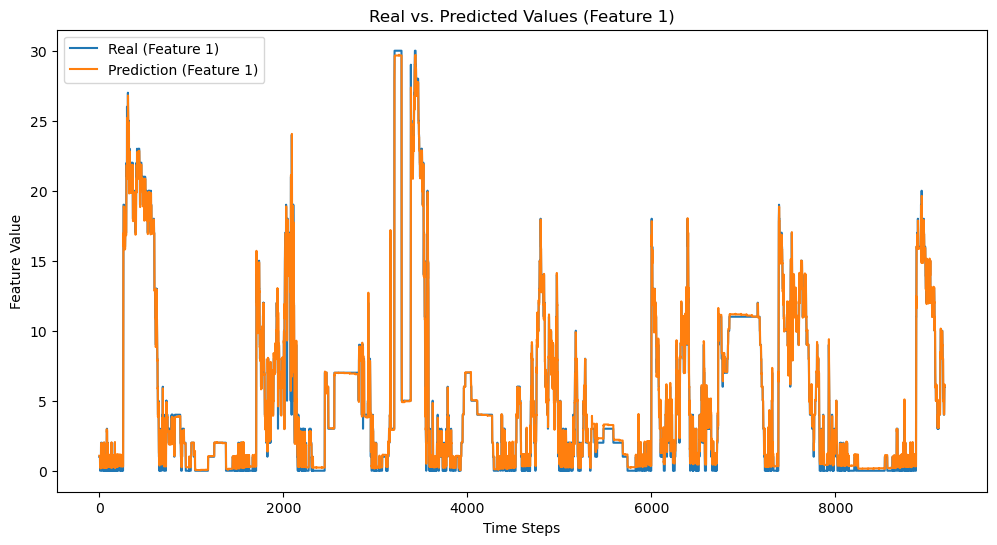

In [58]:
# Draw the figure
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)
ax.plot(y_test_original[:, 0], label="Real (Feature 1)") # Plot the first feature
ax.plot(predictions[:, 0], label="Prediction (Feature 1)") # Plot the first predicted feature
ax.legend(loc='upper left')
plt.xlabel("Time Steps")
plt.ylabel("Feature Value")
plt.title("Real vs. Predicted Values (Feature 1)")
plt.show()